# **Import Libraries**

In [16]:
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold

In [17]:
from utils.experiment_separator import (
    separate_experiments,
    get_experiment_summary,
    print_experiment_report,
    get_experiments,
)

# **Import Dataset**

In [18]:
PATH = "../data/data.csv"
df_raw = pd.read_csv(PATH)

# **Rename Columns**

In [19]:
df = df_raw.copy()
df.columns = ['density', 'cutting_speed', 'feed_rate', 'depth', 'axial_force', 'cutting_force']
TARGET   = 'cutting_force'
FEATURES = ['density', 'cutting_speed', 'feed_rate', 'depth']
INPUT = ['density', 'cutting_speed', 'feed_rate', 'depth', 'axial_force']

# **Separate Experiments**

In [20]:
df = separate_experiments(df)
print_experiment_report(df)
experiments = get_experiments(df)

Total unique combinations : 72
Experiment count range    : 2 – 3
Total experiments         : 198

── Experiments per combination ──
 density  cutting_speed  feed_rate  experiment_count
      10             10         10                 3
      10             10         15                 3
      10             10         20                 3
      10             16         10                 3
      10             16         15                 3
      10             16         20                 3
      10             25         10                 3
      10             25         15                 3
      10             25         20                 3
      10             40         10                 3
      10             40         15                 3
      10             40         20                 3
      10             63         10                 3
      10             63         15                 3
      10             63         20                 3
      10            

# **Preprocessing Pipeline**

## Data Cleaning

In [21]:
def apply_remove_null(df: pd.DataFrame) -> pd.DataFrame:
    return df.dropna()

## Data Scaling

In [22]:
def apply_scaling(df: pd.DataFrame, scaler: MinMaxScaler, fit: bool = False) -> pd.DataFrame:
    cols = INPUT + [TARGET]
    if fit:
        df[cols] = scaler.fit_transform(df[cols])
    else:
        df[cols] = scaler.transform(df[cols])
    return df

## Feature Engineering

In [23]:
def apply_add_feature(df: pd.DataFrame) -> pd.DataFrame:
    return df

## Data Pipeline

In [24]:
class Pipeline:
    def __init__(self):
        self.scaler = MinMaxScaler()

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        temp = df.copy()
        temp = apply_remove_null(temp)
        temp = apply_scaling(temp, self.scaler, fit=True)
        temp = apply_add_feature(temp)
        return temp

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        temp = df.copy()
        temp = apply_remove_null(temp)
        temp = apply_scaling(temp, self.scaler, fit=False)
        temp = apply_add_feature(temp)
        return temp

# **Train/Val Split**

In [25]:
exp_keys = list(experiments.keys())
random.seed(42)
random.shuffle(exp_keys)

n_total = len(exp_keys)
n_train = int(n_total * 0.8)
n_val   = n_total - n_train

train_keys = exp_keys[:n_train]
val_keys   = exp_keys[n_train:]

print(f"\nTotal experiments : {n_total}")
print(f"Train experiments : {len(train_keys)}")
print(f"Val experiments   : {len(val_keys)}")

def experiments_to_tensor(keys, experiments, pipeline, fit=False):
    ref_df = pd.concat([experiments[k] for k in keys], ignore_index=True)
    processed = pipeline.fit_transform(ref_df) if fit else pipeline.transform(ref_df)
    X = torch.tensor(processed[INPUT].values, dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(processed[TARGET].values,   dtype=torch.float32).unsqueeze(1)
    return X, y


Total experiments : 198
Train experiments : 158
Val experiments   : 40


# **Modeling**

In [26]:
INPUT_SIZE  = len(INPUT)
OUTPUT_SIZE = 1
N_FOLDS     = 3

## Training Loop

In [27]:
def train(model_class, model_name: str, experiments: dict, train_keys: list, val_keys: list):
    kf             = KFold(n_splits=N_FOLDS, shuffle=False)
    train_key_arr  = np.array(train_keys, dtype=object)
    fold_val_losses = []

    print(f"\n── Training {model_name} ──")

    for fold, (fold_train_idx, fold_val_idx) in enumerate(kf.split(train_key_arr)):
        fold_train_keys = [tuple(k) for k in train_key_arr[fold_train_idx]]
        fold_val_keys   = [tuple(k) for k in train_key_arr[fold_val_idx]]
        
        model     = model_class()
        pipeline  = Pipeline()
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=model.lr)

        X_fold_train, y_fold_train = experiments_to_tensor(fold_train_keys, experiments, pipeline, fit=True)
        X_fold_val,   y_fold_val   = experiments_to_tensor(fold_val_keys,   experiments, pipeline, fit=False)

        train_loader = DataLoader(TensorDataset(X_fold_train, y_fold_train), batch_size=model.batch_size, shuffle=True)

        for epoch in range(model.epochs):
            model.train()
            train_loss = 0
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_fold_val), y_fold_val).item()

            if True:
                print(f"  Fold {fold+1}/{N_FOLDS} | Epoch {epoch+1}/{model.epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

        fold_val_losses.append(val_loss)

    print(f"\n  KFold Val Loss per fold : {[f'{v:.4f}' for v in fold_val_losses]}")
    print(f"  Mean Val Loss           : {np.mean(fold_val_losses):.4f} ± {np.std(fold_val_losses):.4f}")
    print(f"\n  Retraining on full train set...")
    final_model    = model_class()
    final_pipeline = Pipeline()
    criterion      = nn.MSELoss()
    optimizer      = torch.optim.Adam(final_model.parameters(), lr=final_model.lr)

    X_train, y_train = experiments_to_tensor(train_keys, experiments, final_pipeline, fit=True)
    train_loader     = DataLoader(TensorDataset(X_train, y_train), batch_size=final_model.batch_size, shuffle=True)

    for epoch in range(final_model.epochs):
        final_model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(final_model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    return final_model, final_pipeline

## Validation Plot

In [28]:
def plot_results(model, model_name, X_val, y_val):
    model.eval()
    with torch.no_grad():
        preds = model(X_val).squeeze().numpy()
    actuals = y_val.squeeze().numpy()

    plt.figure(figsize=(12, 4))
    plt.plot(actuals, label='Actual',    color='steelblue')
    plt.plot(preds,   label='Predicted', color='tomato', linestyle='--')
    plt.title(f"{model_name} — Actual vs Predicted (axial_force)")
    plt.xlabel("Sample")
    plt.ylabel("axial_force (scaled)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## LSTM

In [29]:
class LSTM(nn.Module):
    hidden_size = 64
    num_layers  = 2
    epochs      = 10
    batch_size  = 32
    lr          = 1e-3

    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(INPUT_SIZE, self.hidden_size, self.num_layers, batch_first=True)
        self.fc   = nn.Linear(self.hidden_size, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


── Training LSTM ──
  Fold 1/3 | Epoch 1/10 | Train Loss: 0.0008 | Val Loss: 0.0001
  Fold 1/3 | Epoch 2/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 3/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 4/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 5/10 | Train Loss: 0.0001 | Val Loss: 0.0004
  Fold 1/3 | Epoch 6/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 7/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 8/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 9/10 | Train Loss: 0.0000 | Val Loss: 0.0001
  Fold 1/3 | Epoch 10/10 | Train Loss: 0.0000 | Val Loss: 0.0001
  Fold 2/3 | Epoch 1/10 | Train Loss: 0.0007 | Val Loss: 0.0002
  Fold 2/3 | Epoch 2/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 3/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 4/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 5/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch

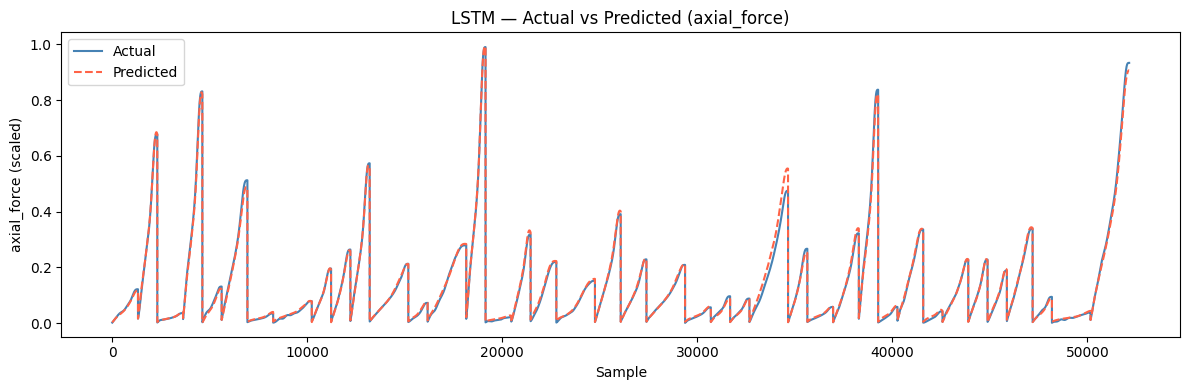

In [30]:
lstm_model, lstm_pipeline = train(LSTM, "LSTM", experiments, train_keys, val_keys)
X_val_lstm, y_val_lstm    = experiments_to_tensor(val_keys, experiments, lstm_pipeline, fit=False)
plot_results(lstm_model, "LSTM", X_val_lstm, y_val_lstm)

## GRU

In [31]:
class GRU(nn.Module):
    hidden_size = 64
    num_layers  = 2
    epochs      = 10
    batch_size  = 32
    lr          = 1e-3

    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(INPUT_SIZE, self.hidden_size, self.num_layers, batch_first=True)
        self.fc  = nn.Linear(self.hidden_size, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


── Training GRU ──
  Fold 1/3 | Epoch 1/10 | Train Loss: 0.0006 | Val Loss: 0.0001
  Fold 1/3 | Epoch 2/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 3/10 | Train Loss: 0.0001 | Val Loss: 0.0002
  Fold 1/3 | Epoch 4/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 5/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 6/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 7/10 | Train Loss: 0.0000 | Val Loss: 0.0000
  Fold 1/3 | Epoch 8/10 | Train Loss: 0.0000 | Val Loss: 0.0000
  Fold 1/3 | Epoch 9/10 | Train Loss: 0.0000 | Val Loss: 0.0000
  Fold 1/3 | Epoch 10/10 | Train Loss: 0.0000 | Val Loss: 0.0000
  Fold 2/3 | Epoch 1/10 | Train Loss: 0.0006 | Val Loss: 0.0002
  Fold 2/3 | Epoch 2/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 3/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 4/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 5/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 

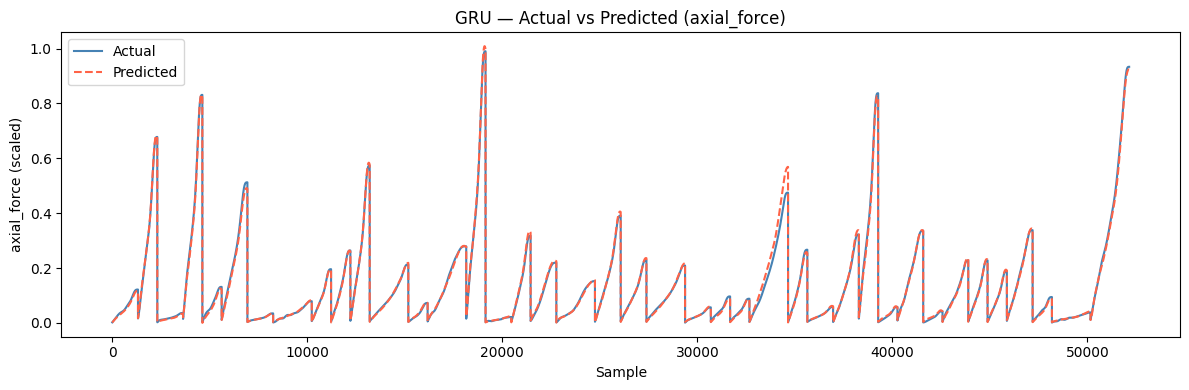

In [32]:
gru_model, gru_pipeline = train(GRU, "GRU", experiments, train_keys, val_keys)
X_val_gru, y_val_gru    = experiments_to_tensor(val_keys, experiments, gru_pipeline, fit=False)
plot_results(gru_model, "GRU", X_val_gru, y_val_gru)

## RNN

In [33]:
class RNN(nn.Module):
    hidden_size = 64
    num_layers  = 2
    epochs      = 10
    batch_size  = 32
    lr          = 1e-3

    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(INPUT_SIZE, self.hidden_size, self.num_layers, batch_first=True)
        self.fc  = nn.Linear(self.hidden_size, OUTPUT_SIZE)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


── Training RNN ──
  Fold 1/3 | Epoch 1/10 | Train Loss: 0.0018 | Val Loss: 0.0002
  Fold 1/3 | Epoch 2/10 | Train Loss: 0.0002 | Val Loss: 0.0001
  Fold 1/3 | Epoch 3/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 4/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 5/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 6/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 1/3 | Epoch 7/10 | Train Loss: 0.0000 | Val Loss: 0.0001
  Fold 1/3 | Epoch 8/10 | Train Loss: 0.0000 | Val Loss: 0.0001
  Fold 1/3 | Epoch 9/10 | Train Loss: 0.0000 | Val Loss: 0.0000
  Fold 1/3 | Epoch 10/10 | Train Loss: 0.0000 | Val Loss: 0.0001
  Fold 2/3 | Epoch 1/10 | Train Loss: 0.0016 | Val Loss: 0.0002
  Fold 2/3 | Epoch 2/10 | Train Loss: 0.0002 | Val Loss: 0.0002
  Fold 2/3 | Epoch 3/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 4/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 5/10 | Train Loss: 0.0001 | Val Loss: 0.0001
  Fold 2/3 | Epoch 

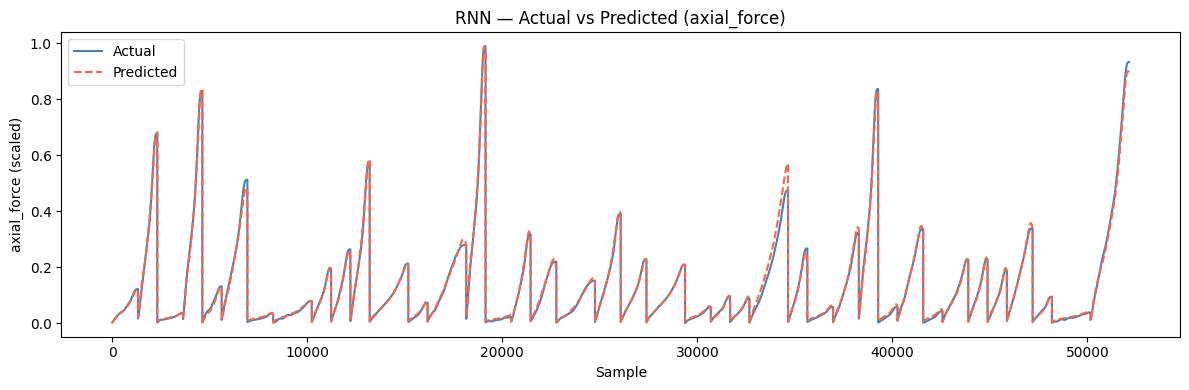

In [34]:
rnn_model, rnn_pipeline = train(RNN, "RNN", experiments, train_keys, val_keys)
X_val_rnn, y_val_rnn    = experiments_to_tensor(val_keys, experiments, rnn_pipeline, fit=False)
plot_results(rnn_model, "RNN", X_val_rnn, y_val_rnn)

# **Evaluation**

In [35]:
def evaluate(model, model_name, X_val, y_val, pipeline):
    model.eval()
    with torch.no_grad():
        preds   = model(X_val).squeeze().numpy()
    actuals = y_val.squeeze().numpy()

    n_cols = len(INPUT) + 1

    dummy_preds           = np.zeros((len(preds), n_cols))
    dummy_preds[:, -1]    = preds
    preds_orig            = pipeline.scaler.inverse_transform(dummy_preds)[:, -1]

    dummy_actuals         = np.zeros((len(actuals), n_cols))
    dummy_actuals[:, -1]  = actuals
    actuals_orig          = pipeline.scaler.inverse_transform(dummy_actuals)[:, -1]

    mae  = mean_absolute_error(actuals_orig, preds_orig)
    mse  = mean_squared_error(actuals_orig, preds_orig)
    rmse = np.sqrt(mse)
    std  = np.std(actuals_orig)

    print(f"── {model_name} ──")
    print(f"  MAE  : {mae:.4f}  ({mae/std*100:.2f}% of std)")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}  ({rmse/std*100:.2f}% of std)")
    print(f"  STD  : {std:.4f}")
    print()


evaluate(lstm_model, "LSTM", X_val_lstm, y_val_lstm, lstm_pipeline)
evaluate(gru_model,  "GRU",  X_val_gru,  y_val_gru,  gru_pipeline)
evaluate(rnn_model,  "RNN",  X_val_rnn,  y_val_rnn,  rnn_pipeline)

── LSTM ──
  MAE  : 8.8403  (3.82% of std)
  MSE  : 246.8729
  RMSE : 15.7122  (6.79% of std)
  STD  : 231.5315

── GRU ──
  MAE  : 7.9792  (3.45% of std)
  MSE  : 235.2858
  RMSE : 15.3390  (6.63% of std)
  STD  : 231.5315

── RNN ──
  MAE  : 9.1483  (3.95% of std)
  MSE  : 266.8537
  RMSE : 16.3357  (7.06% of std)
  STD  : 231.5315

